<a href="https://colab.research.google.com/github/adhiyaaa23/Dashboard-Optimization/blob/main/ecosense_iot_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ File Streamlit app disimpan: ecosense_app.py
   Jalankan dengan: streamlit run ecosense_app.py
  EcoSense: IoT-Energy Optimization Twin
  Astra Honda Motor (AHM) - Tantangan #1

📡 [1/5] Mensimulasikan streaming data IoT sensor...
✅ Dataset IoT Sensor berhasil dibuat.
   Total data points : 1,440
   Durasi            : 2.0 jam
   Anomali injeksi   : 72 titik (5.0%)
   Rata-rata energi  : 41.60 kWh
   Maks energi       : 80.78 kWh

📐 [2/5] Membangun model Multiple Linear Regression...
📐 [MLR Model] Persamaan Energi:
   Y = 40.8941 + 0.2475×X_Temp + 1.8420×X_Load + 0.2885×X_RPM

   R² Train: 0.6764 | R² Test: 0.5864
   MAE Test: 1.1354 kWh | RMSE Test: 1.4558 kWh
   Shapiro-Wilk (residual normal?): p=0.8019 (✅ Normal)

📊 [3/5] Menghitung batas kontrol SPC...
📊 [SPC Control Charts] n=5 per subgroup
   X-bar: 41.603 kWh
   UCL(X-bar): 44.011 | LCL(X-bar): 39.196
   S-bar: 4.172
   UCL(S): 8.716   | LCL(S): 0.000
   Subgroup out-of-control: 105 dari 288 (36.5%)

🔍 Deteksi anomali pada data

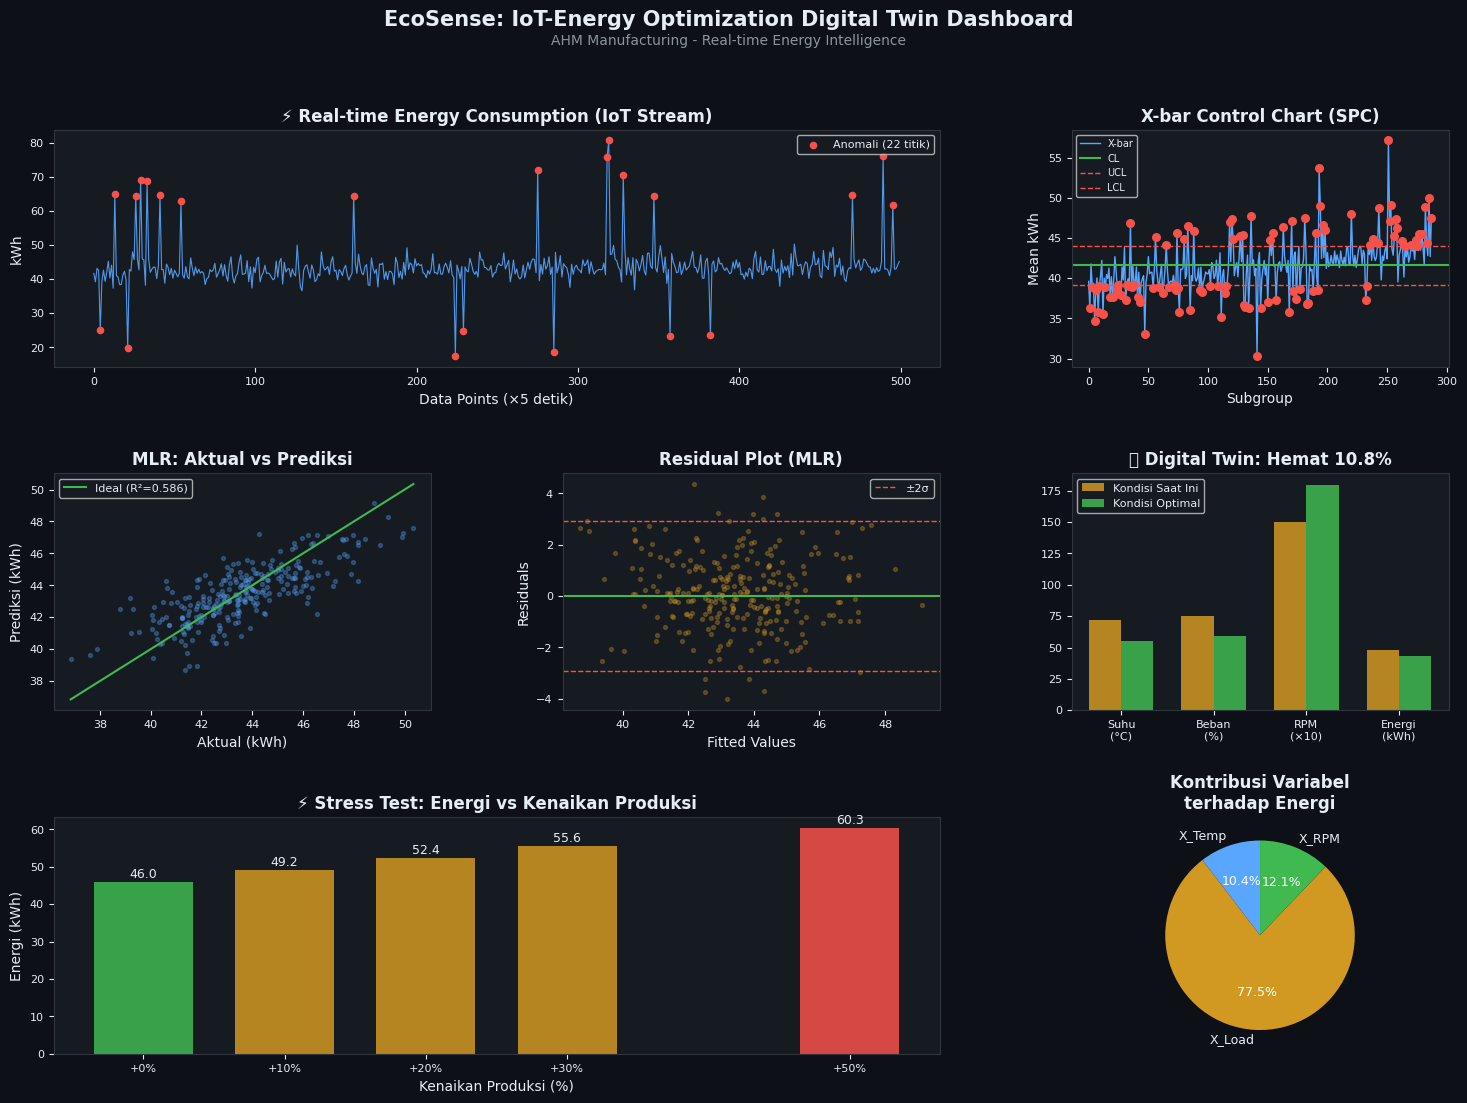

📊 Dashboard disimpan: ecosense_dashboard.png

✅ EcoSense Pipeline selesai!
   Untuk dashboard interaktif, jalankan: streamlit run ecosense_app.py


In [ ]:
# =============================================================================
# Team EcoSense: IoT-Energy Optimization Twin
# Fokus: Efisiensi energi pabrik manufaktur (AHM)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats, optimize
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# pip install scikit-learn scipy pandas numpy matplotlib streamlit


# ─────────────────────────────────────────────────────────────────
# MODUL 1: SIMULASI DATA IoT SENSOR
# ─────────────────────────────────────────────────────────────────

def generate_iot_sensor_data(n_samples=1440, interval_seconds=5, seed=42):
    """
    Mensimulasikan streaming data sensor IoT dari mesin pabrik.
    Menghasilkan data setiap 5 detik selama ~2 jam (1440 titik).

    Variabel Sensor:
    - X_Temp  : Suhu operasional mesin (°C)
    - X_Load  : Beban mesin (% kapasitas)
    - X_RPM   : Kecepatan rotasi (RPM)
    - Y       : Konsumsi energi aktual (kWh)

    Pola Simulasi:
    - Shift pagi (jam 06-14): Beban medium
    - Shift siang (jam 14-22): Beban tinggi
    - Pemeliharaan terjadwal: Lonjakan abnormal acak
    """
    np.random.seed(seed)
    n = n_samples

    # Timeline simulasi: mulai jam 06:00
    timestamps = pd.date_range(
        start='2024-01-15 06:00:00',
        periods=n,
        freq=f'{interval_seconds}s'
    )
    hours = np.array([t.hour + t.minute/60 for t in timestamps])

    # === Variabel Operasional ===

    # Suhu mesin (°C): naik bertahap saat mesin panas, fluktuasi kecil
    temp_base = 65 + 15 * np.sin(2 * np.pi * (hours - 6) / 16)
    X_Temp = temp_base + np.random.normal(0, 2.5, n)
    X_Temp = np.clip(X_Temp, 50, 110)  # Batas operasional wajar

    # Beban mesin (%): lebih tinggi saat shift siang (jam 14-22)
    load_morning = 60 + 10 * np.sin(2 * np.pi * hours / 8)
    load_afternoon = 80 + 8 * np.sin(2 * np.pi * hours / 4)
    X_Load = np.where(hours < 14, load_morning, load_afternoon)
    X_Load += np.random.normal(0, 5, n)
    X_Load = np.clip(X_Load, 30, 100)

    # Kecepatan Rotasi (RPM): proporsional dengan beban
    X_RPM = 1200 + 8 * X_Load + np.random.normal(0, 50, n)
    X_RPM = np.clip(X_RPM, 800, 2200)

    # === Model Konsumsi Energi (Ground Truth) ===
    # Y = β0 + β1*X_Temp + β2*X_Load + β3*X_RPM + ε
    # Koefisien "true" dari proses manufaktur (disimulasikan)
    beta_0 = 10.5       # Konsumsi idle (kWh)
    beta_1 = 0.08       # Pengaruh suhu per °C
    beta_2 = 0.35       # Pengaruh beban per %
    beta_3 = 0.004      # Pengaruh RPM
    epsilon = np.random.normal(0, 1.5, n)  # Error acak

    Y = beta_0 + beta_1*X_Temp + beta_2*X_Load + beta_3*X_RPM + epsilon

    # === Injeksi Anomali (5% data) ===
    anomaly_idx = np.random.choice(n, size=int(0.05*n), replace=False)
    anomaly_type = np.random.choice(['spike', 'drop'], size=len(anomaly_idx))

    for idx, atype in zip(anomaly_idx, anomaly_type):
        if atype == 'spike':
            Y[idx] *= np.random.uniform(1.4, 1.8)   # Lonjakan 40-80%
        else:
            Y[idx] *= np.random.uniform(0.4, 0.6)   # Penurunan drastis

    # Buat label anomali ground truth
    anomaly_labels = np.zeros(n, dtype=bool)
    anomaly_labels[anomaly_idx] = True

    df = pd.DataFrame({
        'timestamp': timestamps,
        'X_Temp': np.round(X_Temp, 2),
        'X_Load': np.round(X_Load, 2),
        'X_RPM': np.round(X_RPM, 1),
        'Y_energy_kWh': np.round(Y, 3),
        'is_anomaly_true': anomaly_labels,
    })

    print("✅ Dataset IoT Sensor berhasil dibuat.")
    print(f"   Total data points : {n:,}")
    print(f"   Durasi            : {(n * interval_seconds / 3600):.1f} jam")
    print(f"   Anomali injeksi   : {anomaly_labels.sum()} titik ({anomaly_labels.mean()*100:.1f}%)")
    print(f"   Rata-rata energi  : {Y.mean():.2f} kWh")
    print(f"   Maks energi       : {Y.max():.2f} kWh\n")

    return df


# ─────────────────────────────────────────────────────────────────
# MODUL 2: MULTIPLE LINEAR REGRESSION (MLR)
# ─────────────────────────────────────────────────────────────────

def build_energy_model(df, test_split=0.2):
    """
    Membangun model Multiple Linear Regression untuk memprediksi konsumsi energi.

    Model: Y = β0 + β1*X_Temp + β2*X_Load + β3*X_RPM + ε

    Args:
        df: DataFrame dengan kolom sensor
        test_split: Proporsi data uji

    Returns:
        dict: Model, scaler, metrics, dan koefisien
    """
    features = ['X_Temp', 'X_Load', 'X_RPM']
    target = 'Y_energy_kWh'

    # Hapus anomali dari training data (bersihkan data)
    df_clean = df[~df['is_anomaly_true']].copy()

    X = df_clean[features].values
    y = df_clean[target].values

    # Split train/test secara kronologis (bukan random, karena data time-series)
    split_idx = int(len(X) * (1 - test_split))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # Standardisasi fitur
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fit MLR
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # Evaluasi
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(np.mean((y_test - y_pred_test)**2))

    # Residual analysis (normalitas dengan Shapiro-Wilk)
    residuals = y_test - y_pred_test
    shapiro_stat, shapiro_p = stats.shapiro(residuals[:min(500, len(residuals))])

    print("📐 [MLR Model] Persamaan Energi:")
    print(f"   Y = {model.intercept_:.4f}", end="")
    for i, (feat, coef) in enumerate(zip(features, model.coef_)):
        sign = "+" if coef >= 0 else "-"
        print(f" {sign} {abs(coef):.4f}×{feat}", end="")
    print("\n")
    print(f"   R² Train: {r2_train:.4f} | R² Test: {r2_test:.4f}")
    print(f"   MAE Test: {mae_test:.4f} kWh | RMSE Test: {rmse_test:.4f} kWh")
    print(f"   Shapiro-Wilk (residual normal?): p={shapiro_p:.4f} "
          f"({'✅ Normal' if shapiro_p > 0.05 else '⚠️ Non-normal'})\n")

    return {
        'model': model,
        'scaler': scaler,
        'features': features,
        'intercept': model.intercept_,
        'coefficients': dict(zip(features, model.coef_)),
        'r2_test': r2_test,
        'mae_test': mae_test,
        'rmse_test': rmse_test,
        'y_pred_test': y_pred_test,
        'y_test': y_test,
        'residuals': residuals,
    }


def predict_energy(model_result, X_Temp, X_Load, X_RPM):
    """
    Prediksi konsumsi energi untuk kondisi mesin tertentu.

    Args:
        model_result: Output dari build_energy_model()
        X_Temp, X_Load, X_RPM: Nilai pengaturan mesin

    Returns:
        float: Prediksi konsumsi energi (kWh)
    """
    X_input = np.array([[X_Temp, X_Load, X_RPM]])
    X_scaled = model_result['scaler'].transform(X_input)
    prediction = model_result['model'].predict(X_scaled)[0]
    return max(0, prediction)


# ─────────────────────────────────────────────────────────────────
# MODUL 3: STATISTICAL PROCESS CONTROL (SPC)
# ─────────────────────────────────────────────────────────────────

def calculate_control_limits(data, subgroup_size=5):
    """
    Menghitung batas kontrol untuk X-bar Chart dan S Chart (Control Charts).
    Digunakan untuk mendeteksi anomali energi secara real-time.

    X-bar Chart: Memantau rata-rata per subgroup
    S Chart    : Memantau variabilitas (standar deviasi) per subgroup

    Args:
        data: Array data konsumsi energi
        subgroup_size: Ukuran subgroup (default 5 = setiap 25 detik)

    Returns:
        dict: Batas kontrol UCL/LCL dan statistik subgroup
    """
    # Faktor SPC standar untuk X-bar & S chart
    # Tabel faktor untuk n=5
    spc_factors = {
        2: {'A3': 1.880, 'B3': 0.000, 'B4': 3.267, 'c4': 0.7979},
        3: {'A3': 1.023, 'B3': 0.000, 'B4': 2.568, 'c4': 0.8862},
        4: {'A3': 0.729, 'B3': 0.000, 'B4': 2.266, 'c4': 0.9213},
        5: {'A3': 0.577, 'B3': 0.000, 'B4': 2.089, 'c4': 0.9400},
        6: {'A3': 0.483, 'B3': 0.030, 'B4': 1.970, 'c4': 0.9515},
        7: {'A3': 0.419, 'B3': 0.118, 'B4': 1.882, 'c4': 0.9594},
        8: {'A3': 0.373, 'B3': 0.185, 'B4': 1.815, 'c4': 0.9650},
        9: {'A3': 0.337, 'B3': 0.239, 'B4': 1.761, 'c4': 0.9693},
        10: {'A3': 0.308, 'B3': 0.284, 'B4': 1.716, 'c4': 0.9727},
    }

    n = subgroup_size
    factors = spc_factors.get(n, spc_factors[5])

    # Bagi data menjadi subgroup
    n_complete = (len(data) // n) * n
    data_trimmed = data[:n_complete]
    subgroups = data_trimmed.reshape(-1, n)

    # Hitung X-bar dan S per subgroup
    xbar = np.mean(subgroups, axis=1)
    s = np.std(subgroups, axis=1, ddof=1)

    # Statistik keseluruhan
    xbar_bar = np.mean(xbar)  # Grand mean
    s_bar = np.mean(s)         # Mean of S

    # === X-bar Chart Control Limits ===
    UCL_xbar = xbar_bar + factors['A3'] * s_bar
    LCL_xbar = xbar_bar - factors['A3'] * s_bar

    # === S Chart Control Limits ===
    UCL_s = factors['B4'] * s_bar
    LCL_s = factors['B3'] * s_bar

    # Deteksi subgroup yang keluar batas (out-of-control)
    ooc_xbar = (xbar > UCL_xbar) | (xbar < LCL_xbar)
    ooc_s = (s > UCL_s) | (s < LCL_s)
    ooc_any = ooc_xbar | ooc_s

    print(f"📊 [SPC Control Charts] n={n} per subgroup")
    print(f"   X-bar: {xbar_bar:.3f} kWh")
    print(f"   UCL(X-bar): {UCL_xbar:.3f} | LCL(X-bar): {LCL_xbar:.3f}")
    print(f"   S-bar: {s_bar:.3f}")
    print(f"   UCL(S): {UCL_s:.3f}   | LCL(S): {LCL_s:.3f}")
    print(f"   Subgroup out-of-control: {ooc_any.sum()} dari {len(xbar)} "
          f"({ooc_any.mean()*100:.1f}%)\n")

    return {
        'xbar': xbar,
        's': s,
        'xbar_bar': xbar_bar,
        's_bar': s_bar,
        'UCL_xbar': UCL_xbar,
        'LCL_xbar': LCL_xbar,
        'UCL_s': UCL_s,
        'LCL_s': LCL_s,
        'ooc_xbar': ooc_xbar,
        'ooc_s': ooc_s,
        'ooc_any': ooc_any,
        'subgroup_size': n,
        'n_subgroups': len(xbar),
    }


def detect_anomalies_realtime(energy_stream, spc_result, threshold_sigma=3):
    """
    Deteksi anomali real-time menggunakan batas kontrol SPC.

    Setiap titik data baru diperiksa terhadap ±3σ dari mean historis.
    Jika keluar batas → flagged sebagai anomali.

    Args:
        energy_stream: Array data energi terbaru
        spc_result: Output dari calculate_control_limits()
        threshold_sigma: Jumlah sigma untuk batas (default: 3)

    Returns:
        dict: Status anomali setiap titik data
    """
    mean = spc_result['xbar_bar']
    std = spc_result['s_bar']

    upper_bound = mean + threshold_sigma * std
    lower_bound = mean - threshold_sigma * std

    anomalies = (energy_stream > upper_bound) | (energy_stream < lower_bound)

    return {
        'energy': energy_stream,
        'anomalies': anomalies,
        'upper_bound': upper_bound,
        'lower_bound': lower_bound,
        'mean': mean,
        'anomaly_count': anomalies.sum(),
        'anomaly_rate': anomalies.mean(),
    }


# ─────────────────────────────────────────────────────────────────
# MODUL 4: CONSTRAINED OPTIMIZATION ENGINE
# ─────────────────────────────────────────────────────────────────

def optimize_machine_settings(model_result, production_target_kwh=None,
                               temp_bounds=(55, 85),
                               load_bounds=(50, 90),
                               rpm_bounds=(1000, 1800)):
    """
    Menggunakan Constrained Optimization untuk menemukan pengaturan mesin (X)
    yang meminimalkan konsumsi energi (Y) tanpa menurunkan target produksi.

    Masalah Optimasi:
        minimize: Y = f(X_Temp, X_Load, X_RPM)
        subject to:
            X_Load × X_RPM ≥ production_proxy  (target produksi terpenuhi)
            X_Temp_min ≤ X_Temp ≤ X_Temp_max
            X_Load_min ≤ X_Load ≤ X_Load_max
            X_RPM_min  ≤ X_RPM  ≤ X_RPM_max

    Args:
        model_result: Output dari build_energy_model()
        production_target_kwh: Batas minimum output produksi (proxy)
        temp_bounds, load_bounds, rpm_bounds: Batas operasional mesin

    Returns:
        dict: Pengaturan optimal dan potensi penghematan
    """
    # Estimasi kondisi operasional "normal" saat ini (rata-rata data)
    # Biasanya diambil dari rata-rata 1 jam terakhir sensor
    current_temp = 72.0
    current_load = 75.0
    current_rpm = 1500.0

    current_energy = predict_energy(model_result, current_temp, current_load, current_rpm)

    # Proxy produksi: Load × RPM harus ≥ 95% dari kondisi saat ini
    production_proxy = current_load * current_rpm * 0.95
    if production_target_kwh:
        production_proxy = production_target_kwh

    # Fungsi objektif: minimisasi energi
    def objective(X):
        temp, load, rpm = X
        return predict_energy(model_result, temp, load, rpm)

    # Constraint: Proxy produksi harus terpenuhi
    constraints = [
        {
            'type': 'ineq',
            'fun': lambda X: X[1] * X[2] - production_proxy  # Load × RPM ≥ target
        }
    ]

    # Batas operasional mesin
    bounds = [temp_bounds, load_bounds, rpm_bounds]

    # Titik awal: kondisi saat ini
    x0 = [current_temp, current_load, current_rpm]

    # Jalankan optimasi dengan metode SLSQP (Sequential Least Squares Programming)
    result = optimize.minimize(
        objective,
        x0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 1000}
    )

    if result.success:
        opt_temp, opt_load, opt_rpm = result.x
        opt_energy = result.fun
        energy_saving = current_energy - opt_energy
        saving_pct = (energy_saving / current_energy) * 100

        # Estimasi penghematan tahunan (asumsi 8000 jam operasional/tahun)
        # Harga listrik industri: ~Rp 1.500/kWh
        annual_hours = 8000
        tariff_per_kwh = 1500  # Rupiah
        annual_saving_kwh = energy_saving * annual_hours
        annual_saving_rp = annual_saving_kwh * tariff_per_kwh

        print("🎯 [Optimization Engine] Hasil Optimasi Pengaturan Mesin:")
        print(f"\n   {'Parameter':<15} {'Saat Ini':>12} {'Optimal':>12} {'Delta':>10}")
        print(f"   {'─'*52}")
        print(f"   {'Suhu (°C)':<15} {current_temp:>12.2f} {opt_temp:>12.2f} {opt_temp-current_temp:>+10.2f}")
        print(f"   {'Beban (%)':<15} {current_load:>12.2f} {opt_load:>12.2f} {opt_load-current_load:>+10.2f}")
        print(f"   {'RPM':<15} {current_rpm:>12.1f} {opt_rpm:>12.1f} {opt_rpm-current_rpm:>+10.1f}")
        print(f"   {'─'*52}")
        print(f"   {'Energi (kWh)':<15} {current_energy:>12.3f} {opt_energy:>12.3f} {-energy_saving:>+10.3f}")
        print(f"\n   ✅ Penghematan: {energy_saving:.3f} kWh ({saving_pct:.2f}%) per jam")
        print(f"   💰 Estimasi penghematan tahunan:")
        print(f"      {annual_saving_kwh:,.0f} kWh = Rp {annual_saving_rp/1e9:.2f} Miliar/tahun\n")

        return {
            'success': True,
            'current': {'temp': current_temp, 'load': current_load, 'rpm': current_rpm, 'energy': current_energy},
            'optimal': {'temp': opt_temp, 'load': opt_load, 'rpm': opt_rpm, 'energy': opt_energy},
            'energy_saving_kWh': energy_saving,
            'saving_pct': saving_pct,
            'annual_saving_kWh': annual_saving_kwh,
            'annual_saving_rp': annual_saving_rp,
            'optimization_result': result,
        }
    else:
        print(f"⚠️  Optimasi gagal konvergen: {result.message}")
        return {'success': False, 'message': result.message}


# ─────────────────────────────────────────────────────────────────
# MODUL 5: STRESS TEST SIMULATOR
# ─────────────────────────────────────────────────────────────────

def stress_test_simulation(model_result, production_increase_pct=20):
    """
    Simulasi Stress Test: "Apa yang terjadi jika produksi naik X%?"

    Mensimulasikan dampak kenaikan produksi terhadap konsumsi energi
    dan memberikan rekomendasi kapasitas.

    Args:
        model_result: Output dari build_energy_model()
        production_increase_pct: Persentase kenaikan produksi

    Returns:
        dict: Proyeksi kebutuhan energi dan rekomendasi
    """
    print(f"⚡ [Stress Test] Simulasi kenaikan produksi +{production_increase_pct}%")

    scenarios = [0, 10, 20, 30, 50]
    baseline_temp = 70.0
    baseline_load = 70.0
    baseline_rpm = 1400.0

    results = []
    for increase in scenarios:
        factor = 1 + increase / 100
        new_load = min(baseline_load * factor, 100)
        new_rpm = min(baseline_rpm * factor, 2200)
        new_temp = baseline_temp + increase * 0.3  # Suhu naik ~0.3°C per % kenaikan produksi

        energy = predict_energy(model_result, new_temp, new_load, new_rpm)

        results.append({
            'Kenaikan Produksi (%)': increase,
            'Suhu (°C)': round(new_temp, 1),
            'Beban (%)': round(new_load, 1),
            'RPM': round(new_rpm, 1),
            'Energi (kWh)': round(energy, 3),
        })

    df_stress = pd.DataFrame(results)
    baseline_energy = df_stress.iloc[0]['Energi (kWh)']
    df_stress['Delta Energi (kWh)'] = (df_stress['Energi (kWh)'] - baseline_energy).round(3)
    df_stress['Delta Energi (%)'] = ((df_stress['Delta Energi (kWh)'] / baseline_energy) * 100).round(2)

    print(df_stress.to_string(index=False))

    # Proyeksi khusus untuk kenaikan yang diminta
    target_idx = df_stress[df_stress['Kenaikan Produksi (%)'] == production_increase_pct]
    if not target_idx.empty:
        row = target_idx.iloc[0]
        print(f"\n   📌 Jika produksi naik {production_increase_pct}%:")
        print(f"      Energi dibutuhkan: {row['Energi (kWh)']:.3f} kWh (+{row['Delta Energi (%)']:.1f}%)")
        print(f"      Perlu memastikan kapasitas daya tersedia untuk tambahan "
              f"{row['Delta Energi (kWh)']:.3f} kWh\n")

    return df_stress


# ─────────────────────────────────────────────────────────────────
# MODUL 6: DIGITAL TWIN VISUALISASI
# ─────────────────────────────────────────────────────────────────

def visualize_digital_twin(df, spc_result, model_result, opt_result, stress_df):
    """
    Dashboard "Digital Twin" - menampilkan status saat ini vs status paling hemat.
    """
    fig = plt.figure(figsize=(18, 12))
    fig.patch.set_facecolor('#0d1117')
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # Warna tema
    C_BLUE = '#58a6ff'
    C_GREEN = '#3fb950'
    C_RED = '#f85149'
    C_ORANGE = '#d29922'
    C_BG = '#161b22'
    C_TEXT = '#e6edf3'

    def style_ax(ax):
        ax.set_facecolor(C_BG)
        ax.tick_params(colors=C_TEXT, labelsize=8)
        ax.xaxis.label.set_color(C_TEXT)
        ax.yaxis.label.set_color(C_TEXT)
        ax.title.set_color(C_TEXT)
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363d')

    # ── Panel 1: Energi Aktual (Real-time stream simulasi) ──
    ax1 = fig.add_subplot(gs[0, :2])
    style_ax(ax1)
    n_display = min(500, len(df))
    energy_display = df['Y_energy_kWh'].values[-n_display:]
    anomaly_display = df['is_anomaly_true'].values[-n_display:]
    ax1.plot(range(n_display), energy_display, color=C_BLUE, linewidth=0.8, alpha=0.9)
    anom_idx = np.where(anomaly_display)[0]
    ax1.scatter(anom_idx, energy_display[anom_idx], color=C_RED, s=20, zorder=5,
                label=f'Anomali ({len(anom_idx)} titik)')
    ax1.set_title('⚡ Real-time Energy Consumption (IoT Stream)', fontweight='bold')
    ax1.set_xlabel('Data Points (×5 detik)')
    ax1.set_ylabel('kWh')
    ax1.legend(facecolor=C_BG, labelcolor=C_TEXT, fontsize=8)

    # ── Panel 2: X-bar Control Chart ──
    ax2 = fig.add_subplot(gs[0, 2])
    style_ax(ax2)
    xbar = spc_result['xbar']
    ax2.plot(xbar, color=C_BLUE, linewidth=1, label='X-bar')
    ax2.axhline(spc_result['xbar_bar'], color=C_GREEN, linestyle='-', linewidth=1.5, label='CL')
    ax2.axhline(spc_result['UCL_xbar'], color=C_RED, linestyle='--', linewidth=1, label='UCL')
    ax2.axhline(spc_result['LCL_xbar'], color=C_RED, linestyle='--', linewidth=1, label='LCL')
    ooc_x = np.where(spc_result['ooc_xbar'])[0]
    ax2.scatter(ooc_x, xbar[ooc_x], color=C_RED, s=30, zorder=5)
    ax2.set_title('X-bar Control Chart (SPC)', fontweight='bold')
    ax2.set_xlabel('Subgroup')
    ax2.set_ylabel('Mean kWh')
    ax2.legend(facecolor=C_BG, labelcolor=C_TEXT, fontsize=7)

    # ── Panel 3: MLR Actual vs Predicted ──
    ax3 = fig.add_subplot(gs[1, 0])
    style_ax(ax3)
    y_test = model_result['y_test']
    y_pred = model_result['y_pred_test']
    ax3.scatter(y_test, y_pred, alpha=0.3, s=8, color=C_BLUE)
    min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax3.plot([min_val, max_val], [min_val, max_val], color=C_GREEN, linewidth=1.5,
             label=f'Ideal (R²={model_result["r2_test"]:.3f})')
    ax3.set_title('MLR: Aktual vs Prediksi', fontweight='bold')
    ax3.set_xlabel('Aktual (kWh)')
    ax3.set_ylabel('Prediksi (kWh)')
    ax3.legend(facecolor=C_BG, labelcolor=C_TEXT, fontsize=8)

    # ── Panel 4: Residual Plot ──
    ax4 = fig.add_subplot(gs[1, 1])
    style_ax(ax4)
    residuals = model_result['residuals']
    ax4.scatter(y_pred, residuals, alpha=0.3, s=8, color=C_ORANGE)
    ax4.axhline(0, color=C_GREEN, linewidth=1.5)
    ax4.axhline(2*residuals.std(), color=C_RED, linestyle='--', linewidth=1, label='±2σ')
    ax4.axhline(-2*residuals.std(), color=C_RED, linestyle='--', linewidth=1)
    ax4.set_title('Residual Plot (MLR)', fontweight='bold')
    ax4.set_xlabel('Fitted Values')
    ax4.set_ylabel('Residuals')
    ax4.legend(facecolor=C_BG, labelcolor=C_TEXT, fontsize=8)

    # ── Panel 5: Digital Twin Comparison (Saat ini vs Optimal) ──
    ax5 = fig.add_subplot(gs[1, 2])
    style_ax(ax5)
    if opt_result['success']:
        params = ['Suhu\n(°C)', 'Beban\n(%)', 'RPM\n(×10)', 'Energi\n(kWh)']
        current_vals = [
            opt_result['current']['temp'],
            opt_result['current']['load'],
            opt_result['current']['rpm'] / 10,
            opt_result['current']['energy']
        ]
        optimal_vals = [
            opt_result['optimal']['temp'],
            opt_result['optimal']['load'],
            opt_result['optimal']['rpm'] / 10,
            opt_result['optimal']['energy']
        ]
        x = np.arange(len(params))
        w = 0.35
        ax5.bar(x - w/2, current_vals, w, label='Kondisi Saat Ini', color=C_ORANGE, alpha=0.85)
        ax5.bar(x + w/2, optimal_vals, w, label='Kondisi Optimal', color=C_GREEN, alpha=0.85)
        ax5.set_title(f'🔮 Digital Twin: Hemat {opt_result["saving_pct"]:.1f}%', fontweight='bold')
        ax5.set_xticks(x)
        ax5.set_xticklabels(params, fontsize=8)
        ax5.legend(facecolor=C_BG, labelcolor=C_TEXT, fontsize=8)

    # ── Panel 6: Stress Test ──
    ax6 = fig.add_subplot(gs[2, :2])
    style_ax(ax6)
    scenarios = stress_df['Kenaikan Produksi (%)'].values
    energies = stress_df['Energi (kWh)'].values
    colors_stress = [C_GREEN if e == energies.min() else C_ORANGE if e < energies.max()
                     else C_RED for e in energies]
    bars = ax6.bar(scenarios, energies, color=colors_stress, alpha=0.85, width=7)
    for bar, val in zip(bars, energies):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', color=C_TEXT, fontsize=9)
    ax6.set_title('⚡ Stress Test: Energi vs Kenaikan Produksi', fontweight='bold')
    ax6.set_xlabel('Kenaikan Produksi (%)')
    ax6.set_ylabel('Energi (kWh)')
    ax6.set_xticks(scenarios)
    ax6.set_xticklabels([f'+{s}%' for s in scenarios])

    # ── Panel 7: Feature Importance (Koefisien MLR) ──
    ax7 = fig.add_subplot(gs[2, 2])
    style_ax(ax7)
    feat_names = list(model_result['coefficients'].keys())
    feat_coefs = [abs(v) for v in model_result['coefficients'].values()]
    total = sum(feat_coefs)
    feat_pct = [v/total*100 for v in feat_coefs]
    wedges, texts, autotexts = ax7.pie(
        feat_pct,
        labels=feat_names,
        autopct='%1.1f%%',
        colors=[C_BLUE, C_ORANGE, C_GREEN],
        startangle=90,
        textprops={'color': C_TEXT, 'fontsize': 9}
    )
    for at in autotexts:
        at.set_color('white')
    ax7.set_title('Kontribusi Variabel\nterhadap Energi', fontweight='bold')

    # Title utama
    fig.text(0.5, 0.98, 'EcoSense: IoT-Energy Optimization Digital Twin Dashboard',
             ha='center', va='top', color=C_TEXT, fontsize=15, fontweight='bold')
    fig.text(0.5, 0.96, 'AHM Manufacturing - Real-time Energy Intelligence',
             ha='center', va='top', color='#8b949e', fontsize=10)

    plt.savefig('ecosense_dashboard.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print("📊 Dashboard disimpan: ecosense_dashboard.png")


# ─────────────────────────────────────────────────────────────────
# MODUL 7: PIPELINE UTAMA
# ─────────────────────────────────────────────────────────────────

def run_ecosense_pipeline():
    """
    Pipeline lengkap EcoSense:
    1. Simulasi data IoT sensor
    2. MLR: Model prediksi energi
    3. SPC: Deteksi anomali real-time
    4. Optimization Engine: Cari pengaturan optimal
    5. Stress Test: Proyeksi kenaikan produksi
    6. Digital Twin Dashboard
    """
    print("=" * 60)
    print("  EcoSense: IoT-Energy Optimization Twin")
    print("  Astra Honda Motor (AHM) - Tantangan #1")
    print("=" * 60)

    # 1. Simulasi data IoT
    print("\n📡 [1/5] Mensimulasikan streaming data IoT sensor...")
    df = generate_iot_sensor_data(n_samples=1440, interval_seconds=5)

    # 2. Build MLR Model
    print("📐 [2/5] Membangun model Multiple Linear Regression...")
    model_result = build_energy_model(df)

    # 3. SPC Control Charts
    print("📊 [3/5] Menghitung batas kontrol SPC...")
    energy_data = df['Y_energy_kWh'].values
    spc_result = calculate_control_limits(energy_data, subgroup_size=5)

    # 4. Deteksi anomali real-time (simulasi 100 titik terakhir)
    print("🔍 Deteksi anomali pada data terbaru:")
    recent_energy = df['Y_energy_kWh'].values[-100:]
    anomaly_result = detect_anomalies_realtime(recent_energy, spc_result)
    print(f"   Anomali terdeteksi: {anomaly_result['anomaly_count']} titik "
          f"({anomaly_result['anomaly_rate']*100:.1f}%) dalam 100 pengukuran terakhir\n")

    # 5. Constrained Optimization
    print("🎯 [4/5] Menjalankan engine optimasi pengaturan mesin...")
    opt_result = optimize_machine_settings(model_result)

    # 6. Stress Test
    print("⚡ [5/5] Menjalankan simulasi Stress Test...")
    stress_df = stress_test_simulation(model_result, production_increase_pct=20)

    # 7. Summary laporan
    print(f"\n{'═'*60}")
    print("  RINGKASAN EKSEKUTIF - EcoSense")
    print(f"{'═'*60}")
    print(f"  Model Akurasi (R²)       : {model_result['r2_test']:.4f}")
    print(f"  MAE Prediksi Energi     : {model_result['mae_test']:.4f} kWh")
    print(f"  Anomali Terdeteksi (SPC): {spc_result['ooc_any'].sum()} subgroup")
    if opt_result['success']:
        print(f"  Potensi Hemat Energi    : {opt_result['saving_pct']:.2f}% per jam")
        print(f"  Estimasi Hemat Tahunan  : Rp {opt_result['annual_saving_rp']/1e9:.2f} Miliar")
    print(f"{'═'*60}\n")

    # 8. Visualisasi Digital Twin
    print("📈 Membuat Digital Twin Dashboard...")
    visualize_digital_twin(df, spc_result, model_result, opt_result, stress_df)

    print("\n✅ EcoSense Pipeline selesai!")
    print("   Untuk dashboard interaktif, jalankan: streamlit run ecosense_app.py")

    return df, model_result, spc_result, opt_result, stress_df


# ─────────────────────────────────────────────────────────────────
# MODUL 8: STREAMLIT APP (simpan sebagai ecosense_app.py)
# ─────────────────────────────────────────────────────────────────

STREAMLIT_CODE = '''
# ecosense_app.py - Jalankan dengan: streamlit run ecosense_app.py
import streamlit as st
import numpy as np
import time
from ecosense_iot_optimization import (
    generate_iot_sensor_data,
    build_energy_model,
    calculate_control_limits,
    detect_anomalies_realtime,
    optimize_machine_settings,
    predict_energy,
    stress_test_simulation,
)

st.set_page_config(page_title="EcoSense Digital Twin", page_icon="🌿", layout="wide")
st.title("🌿 EcoSense: IoT-Energy Optimization Digital Twin")
st.caption("AHM Manufacturing Intelligence Platform")

# Load data & model (cached)
@st.cache_resource
def load_models():
    df = generate_iot_sensor_data(n_samples=1440)
    model_r = build_energy_model(df)
    spc_r = calculate_control_limits(df["Y_energy_kWh"].values, subgroup_size=5)
    return df, model_r, spc_r

with st.spinner("Memuat model dan data sensor..."):
    df, model_result, spc_result = load_models()

# === Tabs ===
tab1, tab2, tab3, tab4 = st.tabs(
    ["🔴 Real-time Monitor", "🎯 Optimization", "⚡ Stress Test", "📊 Model Info"]
)

with tab1:
    st.subheader("Monitoring Energi Real-time")
    col1, col2, col3, col4 = st.columns(4)

    latest = df.iloc[-1]
    col1.metric("Suhu Mesin", f"{latest.X_Temp:.1f}°C")
    col2.metric("Beban Mesin", f"{latest.X_Load:.1f}%")
    col3.metric("RPM", f"{latest.X_RPM:.0f}")
    col4.metric("Energi Aktual", f"{latest.Y_energy_kWh:.2f} kWh")

    n_display = st.slider("Tampilkan N data terakhir", 100, 1000, 300)
    display_df = df.tail(n_display)
    st.line_chart(display_df.set_index("timestamp")["Y_energy_kWh"])

    anomaly_result = detect_anomalies_realtime(
        display_df["Y_energy_kWh"].values, spc_result
    )
    if anomaly_result["anomaly_count"] > 0:
        st.error(f"⚠️ {anomaly_result['anomaly_count']} anomali terdeteksi dalam {n_display} data terakhir!")
    else:
        st.success("✅ Semua data dalam batas normal (SPC)")

with tab2:
    st.subheader("🎯 Optimasi Pengaturan Mesin")
    col1, col2 = st.columns(2)
    with col1:
        st.markdown("**Atur kondisi mesin saat ini:**")
        c_temp = st.slider("Suhu Saat Ini (°C)", 55.0, 100.0, 72.0, step=0.5)
        c_load = st.slider("Beban Saat Ini (%)", 40.0, 100.0, 75.0, step=1.0)
        c_rpm = st.slider("RPM Saat Ini", 800, 2200, 1500, step=50)

    current_e = predict_energy(model_result, c_temp, c_load, c_rpm)

    with col2:
        st.markdown("**Hasil Prediksi & Optimasi:**")
        st.metric("Energi Saat Ini", f"{current_e:.3f} kWh")

        if st.button("🚀 Cari Pengaturan Optimal", use_container_width=True):
            with st.spinner("Menjalankan constrained optimization..."):
                opt = optimize_machine_settings(model_result)
            if opt["success"]:
                col_a, col_b = st.columns(2)
                col_a.metric("Energi Optimal", f"{opt['optimal']['energy']:.3f} kWh",
                             delta=f"-{opt['energy_saving_kWh']:.3f} kWh")
                col_b.metric("Penghematan", f"{opt['saving_pct']:.2f}%")
                st.success(f"💰 Estimasi hemat: Rp {opt['annual_saving_rp']/1e9:.2f} Miliar/tahun")
                st.write("**Rekomendasi Pengaturan Optimal:**")
                st.write({
                    "Suhu": f"{opt['optimal']['temp']:.1f}°C",
                    "Beban": f"{opt['optimal']['load']:.1f}%",
                    "RPM": f"{opt['optimal']['rpm']:.0f}",
                })

with tab3:
    st.subheader("⚡ Stress Test - Proyeksi Kenaikan Produksi")
    increase = st.slider("Simulasikan kenaikan produksi (%)", 0, 100, 20)
    if st.button("▶️ Jalankan Stress Test", use_container_width=True):
        with st.spinner("Mensimulasikan skenario..."):
            stress_df = stress_test_simulation(model_result, increase)
        st.dataframe(stress_df, use_container_width=True)
        st.bar_chart(stress_df.set_index("Kenaikan Produksi (%)")["Energi (kWh)"])

with tab4:
    st.subheader("📐 Informasi Model MLR")
    st.markdown(f"**R² (Test Set):** {model_result['r2_test']:.4f}")
    st.markdown(f"**MAE:** {model_result['mae_test']:.4f} kWh")
    st.markdown(f"**RMSE:** {model_result['rmse_test']:.4f} kWh")
    st.markdown("**Koefisien Regresi:**")
    st.write({
        "Intercept (β₀)": round(model_result["intercept"], 4),
        **{f"{k} (β{i+1})": round(v, 4) for i, (k, v) in enumerate(model_result["coefficients"].items())}
    })
    st.markdown("**SPC Summary:**")
    st.write({
        "Mean (X-bar)": round(spc_result["xbar_bar"], 3),
        "UCL": round(spc_result["UCL_xbar"], 3),
        "LCL": round(spc_result["LCL_xbar"], 3),
        "Out-of-Control Subgroups": int(spc_result["ooc_any"].sum()),
    })
'''

def save_streamlit_app():
    with open('ecosense_app.py', 'w', encoding='utf-8') as f:
        f.write(STREAMLIT_CODE.strip())
    print("✅ File Streamlit app disimpan: ecosense_app.py")
    print("   Jalankan dengan: streamlit run ecosense_app.py")


# ─────────────────────────────────────────────────────────────────
# ENTRY POINT
# ─────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # Simpan Streamlit app
    save_streamlit_app()

    # Jalankan pipeline utama
    df, model_result, spc_result, opt_result, stress_df = run_ecosense_pipeline()